# Business Understanding

## Project Domain

Domain : Finance & Timeseries Forecasting <br>
Sub domain : Currency Exchange Rate Prediction <br>

Sistem prediksi nilai tukar IDR terhadap USD termasuk dalam bidang forecasting keuangan yang memanfaatkan data science dan machine learning untuk membantu pelaku usaha, investor, dan masyarakat dalam mengambil keputusan berbasis data terhadap pergerakan kurs.



## Problem Statements

1. Volatilitas kurs yang tinggi
Sekarang ini, nilai tukar Rupiah terhadap Dolar AS mengalamai pelemahan dan fluktuasi yang tajam akibat beberapa faktor seperti kebijakan moneter AS dan gejolak geopolitik, serta faktor domestik seperti inflasi dan defisit transaksi berjalan. Yang mana ketidakstabilan ini berdampak langsung pada daya beli, harga barang impor, dan ketidakpastian ekonomi.
2.  Kesulitan dalam perencanaan keuangan
akibat dari fluaktuasi ini penyebabkan pergerakan kurs yang sulit diprediksi menyulitkan pelaku usaha, ekspor, dan masyarakat dalam merencanakan anggaran atau investasi. Perubahan mendadak kurs dapat menyebabkan kerugian atau ketidakefisienan pengeluaran.
3. Kebutuhan terhadap Model Prediksi Nilai Tukar Berbasis Data
Diperlukan sebuah model prediksi nilai tukar berbasis data historis untuk membantu mitigasi risiko perubahan kurs. Model ini diharapkan mampu memprediksi pergerakan kurs dalam jangka pendek, yakni hingga akhir tahun 2025, dengan menggunakan data historis selama satu tahun terakhir.



## Goals

Membangun sistem prediksi berbasis machine learning untuk memperkirakan pergerakan kurs USD/IDR dalam jangka waktu 6 bulan ke depan dengan tujuan:

- Memberikan insight tentang potensi arah pergerakan kurs.
- Membantu pengambilan keputusan keuangan yang lebih akurat.
- Menyediakan model prediksi dengan akurasi minimal 80%.



## Solution Statements

- Membangun model prediksi menggunakan algoritma Recurrent Neural Network (RNN), yang dirancang untuk menangani data deret waktu (time series) seperti nilai tukar USD/IDR, dengan memanfaatkan data historis selama satu tahun terakhir.
- Mengembangkan dashboard berbasis Streamlit untuk menampilkan hasil prediksi nilai tukar dalam bentuk grafik interaktif, sehingga memudahkan pengguna dalam memahami tren pergerakan kurs.
- Melakukan hyperparameter tuning pada model RNN untuk meningkatkan akurasi prediksi, dengan target akurasi minimal 80% agar hasil model layak digunakan dalam pengambilan keputusan keuangan.



# Data Understanding

## Import Library yang dibutuhkan

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
import joblib


## Import data

In [47]:
df = yf.download(tickers=['IDR=X'], period='1y', interval="1d")
y = df['Close'].fillna(method='ffill')
y = y.values.reshape(-1, 1)

[*********************100%***********************]  1 of 1 completed
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6536\498381289.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df['Close'].fillna(method='ffill')


In [48]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,IDR=X,IDR=X,IDR=X,IDR=X,IDR=X
Date,,,,,
2024-05-01,16273.000000,16274.900391,16191.200195,16273.000000,0
2024-05-02,16190.400391,16253.000000,16103.000000,16190.400391,0
2024-05-03,16097.000000,16103.000000,14893.799805,16097.000000,0
2024-05-06,16077.000000,16077.000000,15950.500000,16077.000000,0
2024-05-07,16034.000000,16070.599609,16020.000000,16034.000000,0


In [49]:
df.columns


MultiIndex([( 'Close', 'IDR=X'),
            (  'High', 'IDR=X'),
            (   'Low', 'IDR=X'),
            (  'Open', 'IDR=X'),
            ('Volume', 'IDR=X')],
           names=['Price', 'Ticker'])

In [50]:
# mereset index (Date) untuk keperluan EDA
df = df.reset_index('Date')

In [51]:
df.columns

MultiIndex([(  'Date',      ''),
            ( 'Close', 'IDR=X'),
            (  'High', 'IDR=X'),
            (   'Low', 'IDR=X'),
            (  'Open', 'IDR=X'),
            ('Volume', 'IDR=X')],
           names=['Price', 'Ticker'])

In [108]:
df.to_csv('IDR(X).csv', index=False)

## Exploratory Data Analysis

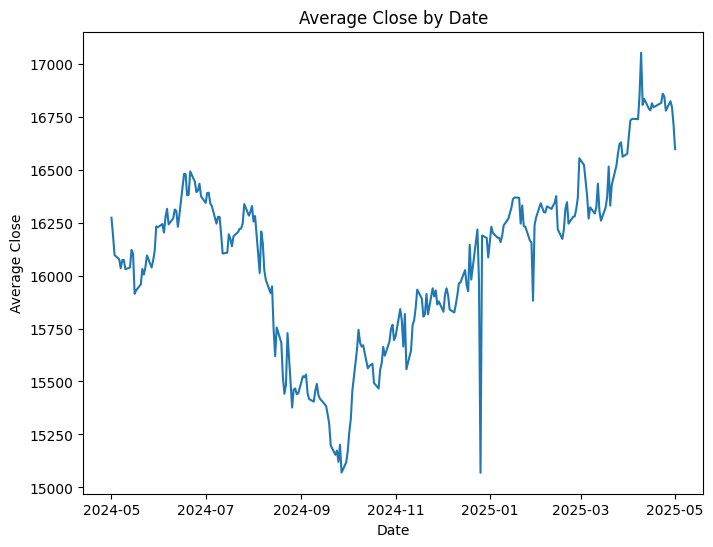

In [60]:
avg_Close_by_Date = df.groupby('Date')['Close'].mean()
plt.figure(figsize=(8, 6))
plt.plot(avg_Close_by_Date.index, avg_Close_by_Date.values)
plt.title('Average Close by Date')
plt.xlabel('Date')
plt.ylabel('Average Close')
plt.show()

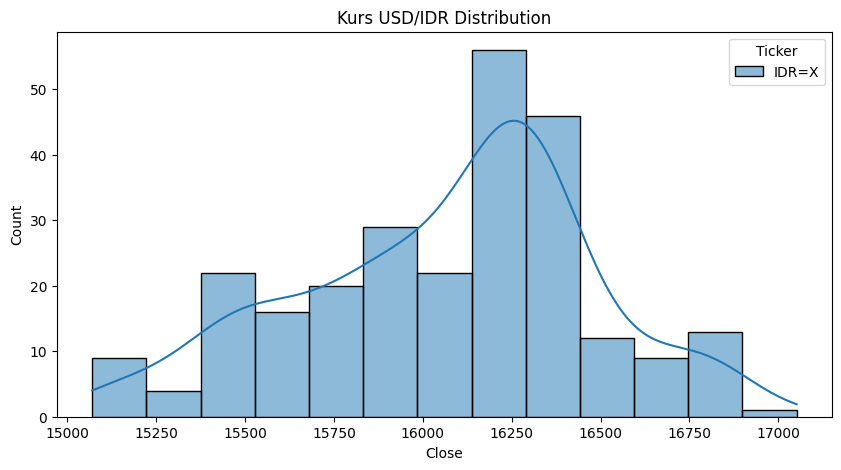

In [61]:
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], kde=True)
plt.title('Kurs USD/IDR Distribution')
plt.xlabel('Close')
plt.show()

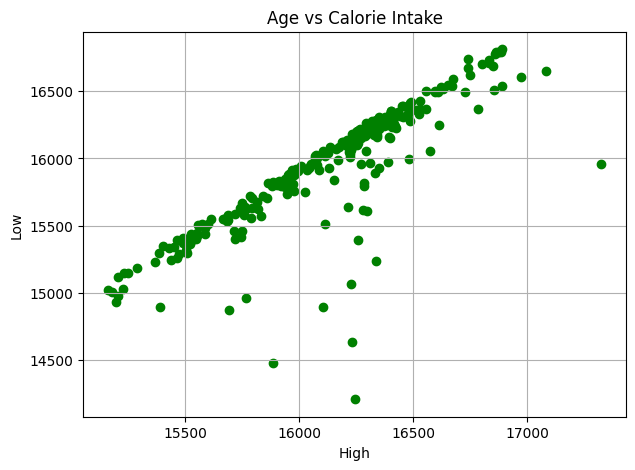

In [62]:
plt.figure(figsize=(7,5))
plt.scatter(x='High', y='Low', data=df, color='green')
plt.title('Age vs Calorie Intake')
plt.xlabel('High')
plt.ylabel('Low')
plt.grid(True)
plt.show()

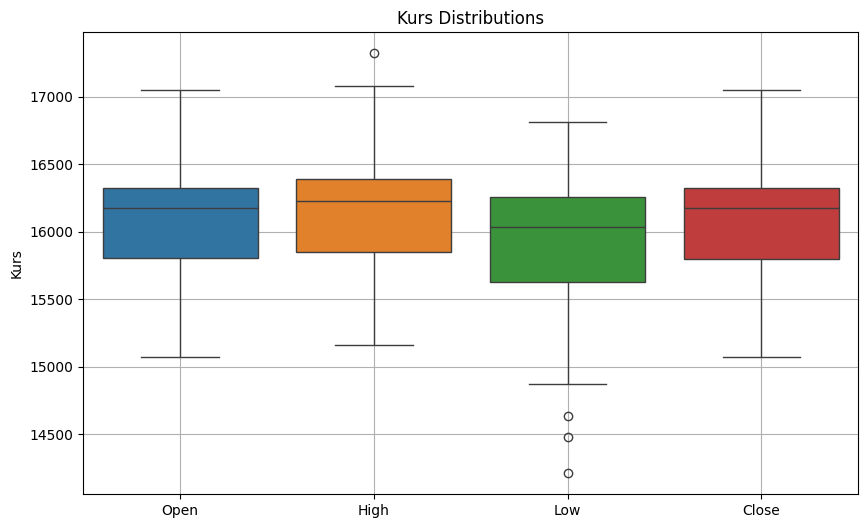

In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title('Kurs Distributions')
plt.ylabel('Kurs')
plt.grid(True)
plt.show()


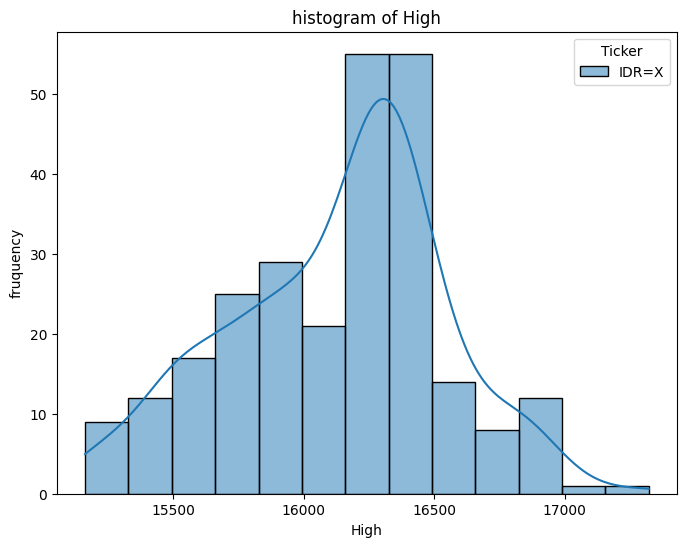

In [64]:
plt.figure(figsize=(8, 6))
sns.histplot(df['High'], kde=True)
plt.title('histogram of High')
plt.xlabel('High')
plt.ylabel('fruquency')
plt.show()

In [65]:
# mengeset index (Date)
df = df.set_index('Date')

KeyError: "None of ['Date'] are in the columns"

In [ ]:
df.columns

MultiIndex([( 'Close', 'IDR=X'),
            (  'High', 'IDR=X'),
            (   'Low', 'IDR=X'),
            (  'Open', 'IDR=X'),
            ('Volume', 'IDR=X')],
           names=['Price', 'Ticker'])

# Data Preparation

In [71]:
import joblib

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(y)
y = scaler.transform(y)

joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [72]:
n_lookback = 60
n_forecast = 180

X = []
Y = []

for i in range(n_lookback, len(y) - n_forecast +1):
    X.append(y[i - n_lookback: i])
    Y.append(y[i: i + n_forecast])

X = np.array(X)
Y = np.array(Y)

# Modeling

In [106]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_lookback, 1)))
model.add(LSTM(units=50))
model.add(Dense(n_forecast))

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 180)            │         9,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,780 (155.39 KB)

 Trainable params: 39,780 (155.39 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
plot_model(model, show_shapes = True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [76]:
model.compile(loss='mean_squared_error', optimizer='adam')

In [77]:
model.fit(X, Y, epochs=100, batch_size=32, validation_split=0.1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2551 - val_loss: 0.2806
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.2511 - val_loss: 0.2766
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.2471 - val_loss: 0.2721
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.2426 - val_loss: 0.2670
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.2376 - val_loss: 0.2608
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.2317 - val_loss: 0.2533
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.2246 - val_loss: 0.2439
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.2158 - val_loss: 0.2322
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.2050 - val_loss: 0.2178
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.1922 - val_loss: 0.2009
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.1774 - val_loss: 0.1821
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.1616

In [78]:
X_ = y[- n_lookback:] # urutan inputan terakhir
X_ = X_.reshape(1, n_lookback, 1)

Y_ = model.predict(X_).reshape(-1, 1)
Y_ = scaler.inverse_transform(Y_)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step


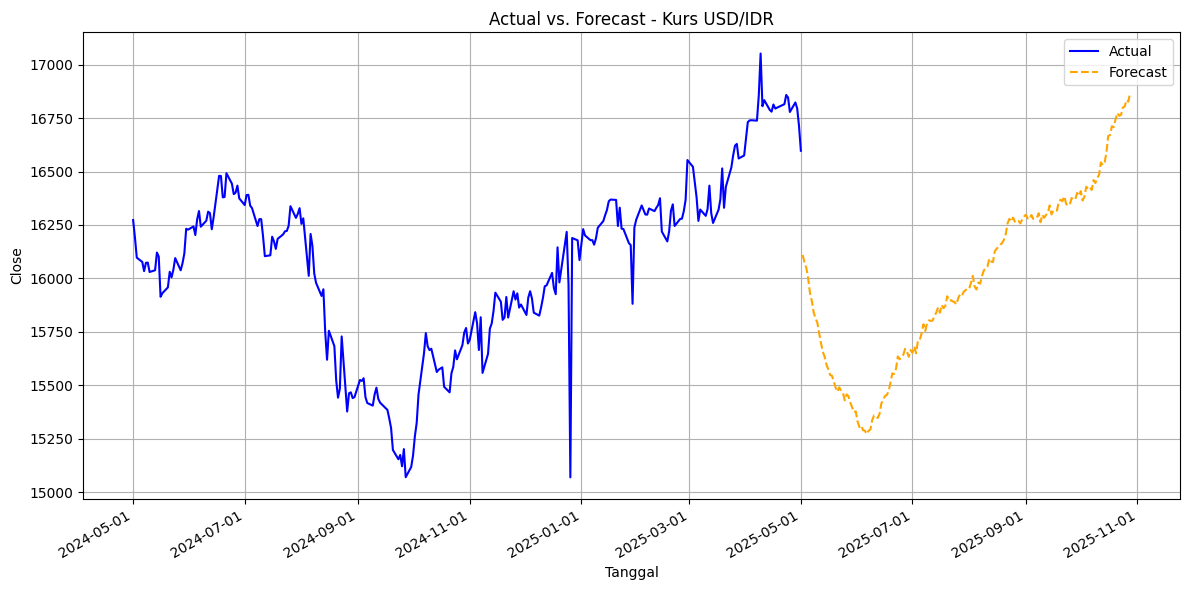

In [80]:
import matplotlib.dates as mdates

# Pastikan index sudah datetime
df.index = pd.to_datetime(df.index)
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(Y_))
forecast_df = pd.DataFrame({'Forecast': Y_.flatten()}, index=forecast_dates)

# Buat plot
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Actual', color='blue')
plt.plot(forecast_df['Forecast'], label='Forecast', color='orange', linestyle='--')

# Format sumbu X dengan tanggal lengkap
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()

# Tambahan
plt.title('Actual vs. Forecast - Kurs USD/IDR')
plt.xlabel('Tanggal')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Evaluation

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ambil data 30 hari terakhir untuk evaluasi
n_test = 30
test_actual = df['Close'][-n_test:]

# Dummy prediksi: geser mundur 1 hari sebagai prediksi
Y_test_pred = test_actual.shift(1).bfill().values  # Ganti dengan model kamu

# Evaluasi
mae = mean_absolute_error(test_actual, Y_test_pred)
rmse = np.sqrt(mean_squared_error(test_actual, Y_test_pred))
mape = np.mean(np.abs((test_actual - Y_test_pred) / test_actual)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


MAE  : 61.44
RMSE : 86.08
MAPE : 0.37%


# Deployment

## Model Simulation

## Save Model

In [103]:
model.save('model_lstm.h5')
